## Linear Regression with Added Features

In the notebook "LinearRegression.ipynb", we used the data we collected to create a baseline model using linear regression. Using the already available features produced a cross-validation MSE of 43.27. Adding harmonic variables (columns that contain "OBSERVATION DATE" data that were transformed using sine and cosine), performing feature selection, and applying regularization yielded a cross-validation MSE of 42.44.

The $R^2$ score on the training data seems to indicate a significant amount of outliers and an apparent lack the variables' predictive power. To attempt to address this issue, we will create new features from the data that we have to reduce the cross-validation MSE.

### Importing necessary packages

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import scipy.stats
import scipy.special
import io
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

import statsmodels.api as sm

### Global variables

In [6]:
lat_min = 38
lat_max = 45
long_min = -90
long_max = -83

data = pd.read_csv("Data/TrainData.csv")

### Helper functions for cross-validation

We will use the same validation data for each of the folds that we used in "LinearRegression.ipynb". This will allow us to make proper comparisons between the results in the current notebook and the results in "LinearRegression.ipynb".

In [9]:
def getCrossValSplit(Features, Responses, Dates):

    ## Create a 4-fold cross validation split. Each validation set will contain 3 months worth of data
    
    validationCutoff5 = (np.datetime64(datetime.datetime(2019,11,1)) - np.datetime64(datetime.datetime(2018,1,1))).astype('timedelta64[D]') // np.timedelta64(1, 'D')
    validationCutoff4 = (np.datetime64(datetime.datetime(2019,9,1)) - np.datetime64(datetime.datetime(2018,1,1))).astype('timedelta64[D]') // np.timedelta64(1, 'D')
    validationCutoff3 = (np.datetime64(datetime.datetime(2019,7,1)) - np.datetime64(datetime.datetime(2018,1,1))).astype('timedelta64[D]') // np.timedelta64(1, 'D')
    validationCutoff2 = (np.datetime64(datetime.datetime(2019,5,1)) - np.datetime64(datetime.datetime(2018,1,1))).astype('timedelta64[D]') // np.timedelta64(1, 'D')
    validationCutoff1 = (np.datetime64(datetime.datetime(2019,3,1)) - np.datetime64(datetime.datetime(2018,1,1))).astype('timedelta64[D]') // np.timedelta64(1, 'D')
    validationCutoff0 = (np.datetime64(datetime.datetime(2019,1,1)) - np.datetime64(datetime.datetime(2018,1,1))).astype('timedelta64[D]') // np.timedelta64(1, 'D')
    
    validationCutoffs = [validationCutoff1, validationCutoff2, validationCutoff3, validationCutoff4, validationCutoff5]
    trainingDates = [Dates[(Dates < validationCutoffs[i]) & (Dates >= validationCutoff0)] for i in range(4)]
    validationDates = [Dates[(Dates < validationCutoffs[i+1]) & (Dates >= validationCutoffs[i])] for i in range(4)]
    trainingInds = list(map(lambda x: x.index, trainingDates))
    validationInds = list(map(lambda x: x.index, validationDates))
    
    trainXs = [Features.loc[trainingInds[i]] for i in range(4)]
    trainYs = [Responses.loc[trainingInds[i]] for i in range(4)]
    validXs = [Features.loc[validationInds[i]] for i in range(4)]
    validYs = [Responses.loc[validationInds[i]] for i in range(4)]


    return trainXs, trainYs, validXs, validYs, trainingDates, validationDates


def getCrossValLinRegMSE(trainXs, trainYs, validXs, validYs):

    ## Compute the cross validation error 
    
    MSEs = np.zeros(4)

    for i in range(4):
        trainX, trainY, validX, validY = trainXs[i], trainYs[i], validXs[i], validYs[i]
        model = sm.OLS(trainY, trainX)
        results = model.fit()
        preds = results.predict(validX)
        MSEs[i] = np.mean(np.power(validY.values-preds, 2))
    
    return np.mean(MSEs)


In [10]:
def processData(data):

    ## Convert qualitative columns into integers and add an intercept column
    
    cols = [
        "IBA CODE",
        "BCR CODE",
        "USFWS CODE",
        "OBSERVATION TYPE_Area",
        "OBSERVATION TYPE_Banding",
        "OBSERVATION TYPE_Historical",
        "OBSERVATION TYPE_Incidental",
        "OBSERVATION TYPE_Nocturnal Flight Call Count",
        "OBSERVATION TYPE_Stationary",
        "OBSERVATION TYPE_Traveling"
    ]
    
    for col in cols:
        data[col] = data[col].astype(int)
    
    data = data.drop(["OBSERVATION TYPE_eBird Pelagic Protocol"], axis = 1)
    data["INTERCEPT"] = np.ones(len(data))
    
    Dates = data["OBSERVATION DATE"]
    X = data.drop("OBSERVATION COUNT", axis = 1)
    Y = data["OBSERVATION COUNT"]

    return X,Y,Dates

### Creating features to address seasonality

We saw in the "LinearRegression.ipynb" notebook that observation counts exhibit periodic behavior; the average observation counts for a day correlate with the average observation counts from one year ago. We will add the feature "PREVIOUS AVERAGE OBSERVATION" that contains the average observation count in a time period of length windowSize centered at the OBSERVATION DATE precisely one year ago.

First, we will compute the average of all the observations in the specified time period and include it in the model

In [14]:
def findWindowAverage(windowSize, data):
    cutoffDate = (np.datetime64(datetime.datetime(2019,1,1)) - np.datetime64(datetime.datetime(2018,1,1))).astype('timedelta64[D]') // np.timedelta64(1, 'D')
    
    temp = data.loc[:,["OBSERVATION DATE", "OBSERVATION COUNT"]]
    temp = temp[temp["OBSERVATION DATE"] < cutoffDate]
    
    temp["NUM OBS"] = np.ones(len(temp))
    
    temp = temp.groupby(by = "OBSERVATION DATE").sum()
    
    res = temp.rolling(windowSize, min_periods = 1, center = True).sum()
    res = res.reset_index()
    res["PREVIOUS AVERAGE OBSERVATION"] = res["OBSERVATION COUNT"]/res["NUM OBS"]

    res = res.drop(["OBSERVATION COUNT", "NUM OBS"], axis = 1)
    
    return res

def addWindowAverage(windowAverage, data):
    windowAverage["OBSERVATION DATE"] = windowAverage["OBSERVATION DATE"] + 365
    
    res = data.merge(windowAverage, how = "left", on = "OBSERVATION DATE")
    
    return res


In [15]:
for i in range(15):
    windowSize = 3 + 2*i
    averaged = findWindowAverage(windowSize, data)
    temp = addWindowAverage(averaged, data)
    X,Y,Dates = processData(temp)
    
    trainXs, trainYs, validXs, validYs, trainDates, validDates = getCrossValSplit(X,Y, Dates)
    print(f"The cross validation error for the model with rolling window of length {windowSize} is {getCrossValLinRegMSE(trainXs, trainYs, validXs, validYs)}")

The cross validation error for the model with rolling window of length 3 is 42.25691360994772
The cross validation error for the model with rolling window of length 5 is 42.251772987786644
The cross validation error for the model with rolling window of length 7 is 42.240592157635604
The cross validation error for the model with rolling window of length 9 is 42.223968581980444
The cross validation error for the model with rolling window of length 11 is 42.215265740938975
The cross validation error for the model with rolling window of length 13 is 42.205193634887046
The cross validation error for the model with rolling window of length 15 is 42.19950550233793
The cross validation error for the model with rolling window of length 17 is 42.19675004366329
The cross validation error for the model with rolling window of length 19 is 42.198117682226666
The cross validation error for the model with rolling window of length 21 is 42.20043849725435
The cross validation error for the model with ro

Next, we will compute the average of all the observations in the specified time period and in the specified grid location (using "LATITUDE" and "LONGITUDE" variables). We will test if incorporating the location data improves the variable quality.

In [17]:
def findWindowAverageByLoc(windowSize, data):
    cutoffDate = (np.datetime64(datetime.datetime(2019,1,1)) - np.datetime64(datetime.datetime(2018,1,1))).astype('timedelta64[D]') // np.timedelta64(1, 'D')
    
    temp = data.loc[:,["OBSERVATION DATE", "LATITUDE", "LONGITUDE", "OBSERVATION COUNT"]]
    temp = temp[temp["OBSERVATION DATE"] < cutoffDate]
    
    temp["LATITUDE ROUNDED"] = np.floor(temp["LATITUDE"])
    temp["LONGITUDE ROUNDED"] = np.floor(temp["LONGITUDE"])
    temp["NUM OBS"] = np.ones(len(temp))
    temp = temp.drop(["LATITUDE","LONGITUDE"], axis = 1)
    
    temp = temp.groupby(by = ["OBSERVATION DATE", "LATITUDE ROUNDED", "LONGITUDE ROUNDED"]).sum()
    res = temp.copy()
    
    for i in range(lat_max - lat_min):
        for j in range(long_max - long_min):
            cur = temp.loc[:,lat_min+i,long_min+j]        
            
            rAvg = cur.rolling(windowSize, min_periods = 1, center = True).sum()
            rAvg = rAvg.reset_index()
            rAvg["LATITUDE ROUNDED"] = lat_min+i
            rAvg["LONGITUDE ROUNDED"] = long_min+j
            rAvg = rAvg.set_index(["OBSERVATION DATE", "LATITUDE ROUNDED", "LONGITUDE ROUNDED"])
            
            res.loc[:,lat_min+i,long_min+j] = rAvg

    res = res.reset_index()
    res["PREVIOUS AVERAGE OBSERVATION"] = res["OBSERVATION COUNT"]/res["NUM OBS"]

    res = res.drop(["OBSERVATION COUNT", "NUM OBS"], axis = 1)
    
    return res


def addWindowAverageByLoc(windowAverage, data):
    windowAverage["OBSERVATION DATE"] = windowAverage["OBSERVATION DATE"] + 365

    data["LATITUDE ROUNDED"] = np.floor(data["LATITUDE"])
    data["LONGITUDE ROUNDED"] = np.floor(data["LONGITUDE"])
    
    res = data.merge(windowAverage, how = "left", on = ["OBSERVATION DATE", "LATITUDE ROUNDED", "LONGITUDE ROUNDED"])
    
    res = res.drop(["LATITUDE ROUNDED", "LONGITUDE ROUNDED"], axis = 1)

    cutoffDate = (np.datetime64(datetime.datetime(2019,1,1)) - np.datetime64(datetime.datetime(2018,1,1))).astype('timedelta64[D]') // np.timedelta64(1, 'D')
    fillValue = np.mean(data[data["OBSERVATION DATE"] < cutoffDate]["OBSERVATION COUNT"])
    
    res = res.fillna(fillValue)

    return res

In [18]:
for i in range(15):
    windowSize = 3 + 2*i
    averaged = findWindowAverageByLoc(windowSize, data)
    temp = addWindowAverageByLoc(averaged, data)
    X,Y,Dates = processData(temp)
    
    trainXs, trainYs, validXs, validYs, trainDates, validDates = getCrossValSplit(X,Y, Dates)
    print(f"The cross validation error for the model with rolling window (by location) of length {windowSize} is {getCrossValLinRegMSE(trainXs, trainYs, validXs, validYs)}")

The cross validation error for the model with rolling window (by location) of length 3 is 42.002525340772955
The cross validation error for the model with rolling window (by location) of length 5 is 41.929091489876946
The cross validation error for the model with rolling window (by location) of length 7 is 41.892099098019614
The cross validation error for the model with rolling window (by location) of length 9 is 41.85580519358751
The cross validation error for the model with rolling window (by location) of length 11 is 41.83244596488711
The cross validation error for the model with rolling window (by location) of length 13 is 41.8110261082865
The cross validation error for the model with rolling window (by location) of length 15 is 41.803768687357255
The cross validation error for the model with rolling window (by location) of length 17 is 41.79343463580882
The cross validation error for the model with rolling window (by location) of length 19 is 41.790736263030375
The cross validatio

There is a noticeable difference! We will use windowSize of 23 to compute the average observation count for the prior year at the same grid location for each of the observations.

In [20]:
windowSize = 23

### Creating features to address correlation between data from adjacent time points

We also saw that observation counts from two adjacent days are correlated. We will add the feature "ROLLING AVERAGE OBSERVATION" that contains a (trailing) rolling average of observation counts from the previous days.

As before, we will first compute the average of all the observations in the previous days and include it in the model.

In [24]:
def findRollingAverage(size, data):
    
    temp = data.loc[:,["OBSERVATION DATE", "OBSERVATION COUNT"]]
    
    temp["NUM OBS"] = np.ones(len(temp))
    
    temp = temp.groupby(by = "OBSERVATION DATE").sum()

    res = temp.rolling(size, min_periods = 1, closed = "left").sum()
    res = res.reset_index()
    res["ROLLING AVERAGE OBSERVATION"] = res["OBSERVATION COUNT"]/res["NUM OBS"]

    res = res.drop(["OBSERVATION COUNT", "NUM OBS"], axis = 1)
    
    return res

def addRollingAverage(rollingAverage, data):
    rollingAverage["OBSERVATION DATE"] = rollingAverage["OBSERVATION DATE"]
    
    res = data.merge(rollingAverage, how = "left", on = "OBSERVATION DATE")
    
    return res


In [25]:
for i in range(7):
    size = i+1
    averaged = findWindowAverageByLoc(windowSize, data)
    temp = addWindowAverageByLoc(averaged, data)

    rolling = findRollingAverage(size,data)
    temp = addRollingAverage(rolling, temp)
    
    X,Y,Dates = processData(temp)
    
    trainXs, trainYs, validXs, validYs, trainDates, validDates = getCrossValSplit(X,Y, Dates)
    print(f"The cross validation error for the model with rolling average length {size} is {getCrossValLinRegMSE(trainXs, trainYs, validXs, validYs)}")

The cross validation error for the model with rolling average length 1 is 41.770567354278434
The cross validation error for the model with rolling average length 2 is 41.77022845882402
The cross validation error for the model with rolling average length 3 is 41.7768106971266
The cross validation error for the model with rolling average length 4 is 41.78814902287126
The cross validation error for the model with rolling average length 5 is 41.789284018535426
The cross validation error for the model with rolling average length 6 is 41.7953099626
The cross validation error for the model with rolling average length 7 is 41.79251597426604


Next, we will compute the average of the observations in the previous days from the same grid location.

In [27]:
def findRollingAverageByLoc(size, data):
    
    temp = data.loc[:,["OBSERVATION DATE", "LATITUDE", "LONGITUDE", "OBSERVATION COUNT"]]
    
    temp["LATITUDE ROUNDED"] = np.floor(temp["LATITUDE"])
    temp["LONGITUDE ROUNDED"] = np.floor(temp["LONGITUDE"])
    temp["NUM OBS"] = np.ones(len(temp))
    temp = temp.drop(["LATITUDE","LONGITUDE"], axis = 1)
    
    temp = temp.groupby(by = ["OBSERVATION DATE", "LATITUDE ROUNDED", "LONGITUDE ROUNDED"]).sum()
    res = temp.copy()
    
    for i in range(lat_max - lat_min):
        for j in range(long_max - long_min):
            cur = temp.loc[:,lat_min+i,long_min+j]        
            
            rAvg = cur.rolling(size, min_periods = 1, closed = "left").sum()
            rAvg = rAvg.reset_index()
            rAvg["LATITUDE ROUNDED"] = lat_min+i
            rAvg["LONGITUDE ROUNDED"] = long_min+j
            rAvg = rAvg.set_index(["OBSERVATION DATE", "LATITUDE ROUNDED", "LONGITUDE ROUNDED"])
            
            res.loc[:,lat_min+i,long_min+j] = rAvg

    res = res.reset_index()
    res["ROLLING AVERAGE OBSERVATION"] = res["OBSERVATION COUNT"]/res["NUM OBS"]

    res = res.drop(["OBSERVATION COUNT", "NUM OBS"], axis = 1)
    
    return res




def addRollingAverageByLoc(rollingAverage, data):

    data["LATITUDE ROUNDED"] = np.floor(data["LATITUDE"])
    data["LONGITUDE ROUNDED"] = np.floor(data["LONGITUDE"])
    
    res = data.merge(rollingAverage, how = "left", on = ["OBSERVATION DATE", "LATITUDE ROUNDED", "LONGITUDE ROUNDED"])
    
    res = res.drop(["LATITUDE ROUNDED", "LONGITUDE ROUNDED"], axis = 1)
    return res
    

In [28]:
for i in range(7):
    size = i+1
    averaged = findWindowAverageByLoc(windowSize, data)
    temp = addWindowAverageByLoc(averaged, data)

    rolling = findRollingAverageByLoc(size,data)
    temp = addRollingAverageByLoc(rolling, temp)
    
    X,Y,Dates = processData(temp)
    
    trainXs, trainYs, validXs, validYs, trainDates, validDates = getCrossValSplit(X,Y, Dates)
    print(f"The cross validation error for the model with rolling average (by location) of length {size} is {getCrossValLinRegMSE(trainXs, trainYs, validXs, validYs)}")

The cross validation error for the model with rolling average (by location) of length 1 is 41.60479116467016
The cross validation error for the model with rolling average (by location) of length 2 is 41.55462183080226
The cross validation error for the model with rolling average (by location) of length 3 is 41.538009596492195
The cross validation error for the model with rolling average (by location) of length 4 is 41.53614426265346
The cross validation error for the model with rolling average (by location) of length 5 is 41.5275127180073
The cross validation error for the model with rolling average (by location) of length 6 is 41.53783633056782
The cross validation error for the model with rolling average (by location) of length 7 is 41.538862178202656


There is a noticeable difference again! We will use a trailing average of 5 days in the model.

In [30]:
size = 5

### Transforming the "DURATION MINUTES" feature

The entries in the "DURATION MINUTES" column are the number of minutes each observation lasted. After using Lasso regularization in the "LinearRegression.ipynb" notebook, we found that "DURATION MINUTES" has significant prediction power. However, the column also contains high leverage observations.

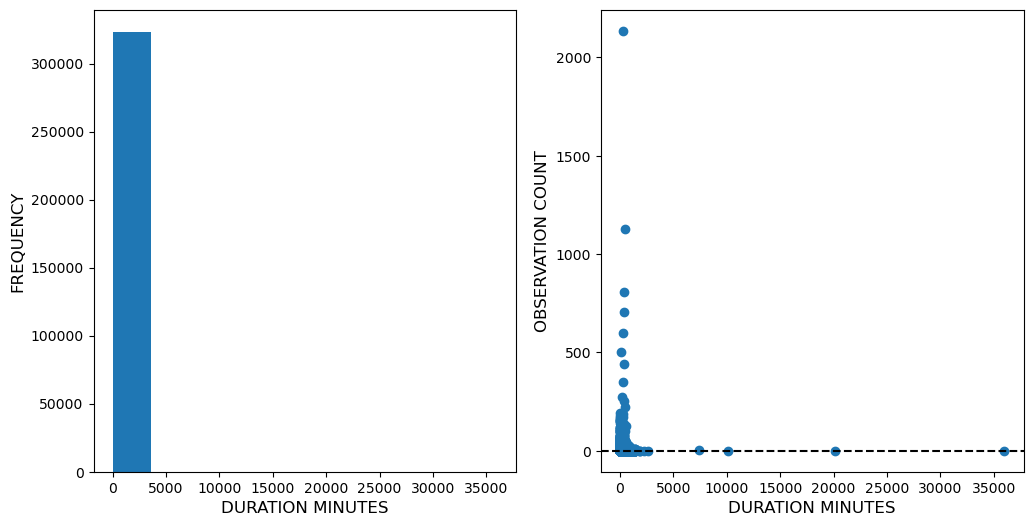

In [33]:
trainX = trainXs[-1]
trainY = trainYs[-1]


fig, ax = plt.subplots(1,2,figsize = (12,6))

ax[0].hist(trainX["DURATION MINUTES"])
ax[0].set_ylabel("FREQUENCY", fontsize=12)
ax[0].set_xlabel("DURATION MINUTES", fontsize=12)


ax[1].scatter(trainX["DURATION MINUTES"], trainY)
ax[1].axhline(0,c='k', ls = '--')
ax[1].set_ylabel("OBSERVATION COUNT", fontsize=12)
ax[1].set_xlabel("DURATION MINUTES", fontsize=12)


plt.show()


We will transform the variable duration minutes to try and address this issue. It is probably the case that the relationship between the number of goldfinches a person observes and the length of the observation is not linear. (Maybe, it is less likely to observe more goldfinches in the same observation after already observing some of them.) So we will transform the function using logarithms and fractional powers.  

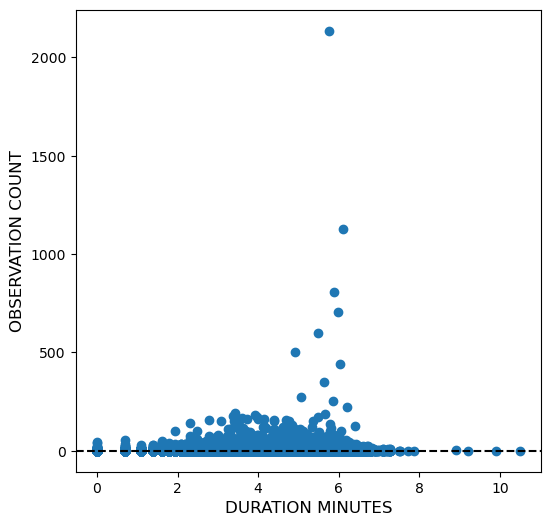

In [35]:
trainX = trainXs[-1]
trainY = trainYs[-1]


fig, ax = plt.subplots(1,1,figsize = (6,6))

ax.scatter(np.log(trainX["DURATION MINUTES"]), trainY)
ax.axhline(0,c='k', ls = '--')
ax.set_ylabel("OBSERVATION COUNT", fontsize=12)
ax.set_xlabel("DURATION MINUTES", fontsize=12)


plt.show()

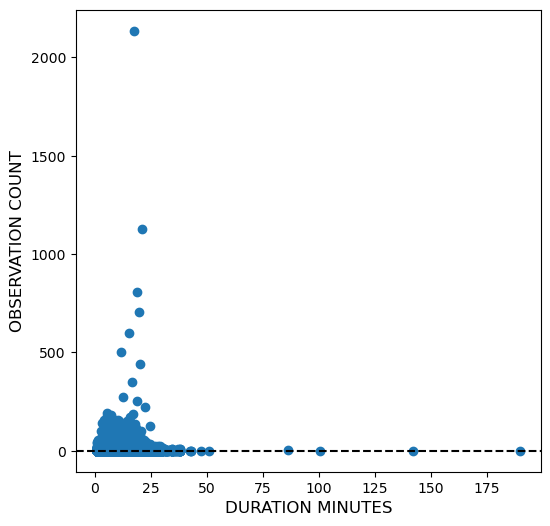

In [36]:
trainX = trainXs[-1]
trainY = trainYs[-1]


fig, ax = plt.subplots(1,1,figsize = (6,6))

ax.scatter(np.sqrt(trainX["DURATION MINUTES"]), trainY)
ax.axhline(0,c='k', ls = '--')
ax.set_ylabel("OBSERVATION COUNT", fontsize=12)
ax.set_xlabel("DURATION MINUTES", fontsize=12)


plt.show()

In [37]:
averaged = findWindowAverageByLoc(windowSize, data)
temp = addWindowAverageByLoc(averaged, data)

rolling = findRollingAverageByLoc(size,data)
temp = addRollingAverageByLoc(rolling, temp)

X,Y,Dates = processData(temp)

X["DURATION MINUTES_TRANSFORMED"] = np.log(X["DURATION MINUTES"].to_numpy())

trainXs, trainYs, validXs, validYs, trainDates, validDates = getCrossValSplit(X,Y, Dates)

print(f"The cross validation error is {getCrossValLinRegMSE(trainXs, trainYs, validXs, validYs)}")

The cross validation error is 40.70597145393293


There is a big improvement after transforming the variable using the logarithm! Let's try transforming "DURATION MINUTES" using fractional exponents.

In [39]:
averaged = findWindowAverageByLoc(windowSize, data)
temp = addWindowAverageByLoc(averaged, data)

rolling = findRollingAverageByLoc(size,data)
temp = addRollingAverageByLoc(rolling, temp)

X,Y,Dates = processData(temp)

fractions = [1/(2+i) for i in range(10)]

for fraction in fractions:
    X["DURATION MINUTES_TRANSFORMED"] = np.power(X["DURATION MINUTES"].to_numpy(), fraction)    
    trainXs, trainYs, validXs, validYs, trainDates, validDates = getCrossValSplit(X,Y, Dates)
    print(f"The cross validation error after transforming using the fractional exponent {fraction} is {getCrossValLinRegMSE(trainXs, trainYs, validXs, validYs)}")

The cross validation error after transforming using the fractional exponent 0.5 is 40.79241045369639
The cross validation error after transforming using the fractional exponent 0.3333333333333333 is 40.64601543679802
The cross validation error after transforming using the fractional exponent 0.25 is 40.62596278426712
The cross validation error after transforming using the fractional exponent 0.2 is 40.62713672687575
The cross validation error after transforming using the fractional exponent 0.16666666666666666 is 40.63269528804594
The cross validation error after transforming using the fractional exponent 0.14285714285714285 is 40.638791252450474
The cross validation error after transforming using the fractional exponent 0.125 is 40.6444465911623
The cross validation error after transforming using the fractional exponent 0.1111111111111111 is 40.64945320623952
The cross validation error after transforming using the fractional exponent 0.1 is 40.65382528690948
The cross validation error

Transforming the variable by taking the fourth root yields slightly better performance. We will include the transformed variable in the model from now on.

In [41]:
fraction = 1/4

### Transforming the "TIME OBSERVATIONS STARTED" feature

We can see from the plot below that the "TIME OBSERVATIONS STARTED" feature likely contains information about the observation counts.

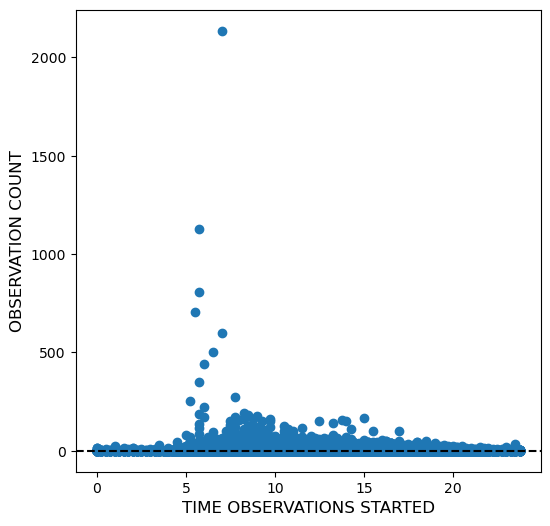

In [44]:
trainX = trainXs[-1]
trainY = trainYs[-1]

fig, ax = plt.subplots(1,1,figsize = (6,6))

ax.scatter(trainX["TIME OBSERVATIONS STARTED"], trainY)
ax.axhline(0,c='k', ls = '--')
ax.set_ylabel("OBSERVATION COUNT", fontsize=12)
ax.set_xlabel("TIME OBSERVATIONS STARTED", fontsize=12)


plt.show()

There are a couple things to note about this feature. First, the feature is periodic because each entry is the time that the observation was started measured in hours (so 12.5 is 12:30PM). We should try our best to transform the variable to preserve the periodicity (since there is no reason not to). Second, there is a "peak" of outlier observations at around 6:00AM and the time window 5:00AM- 1:00PM seem to have more observation counts than other time windows. (Maybe this is when the enthusiastic bird observers wake up so that they can observe the birds before other birders can disrupt their observations. Or, maybe there is a specific time window when goldfinches are active during the day.)

We will try to account for these characateristics in two different ways.

First, we will use the sine function $f(t) = \sin\left ( \frac{\pi}{24}(t + 5) \right )$ to transform the variable.

Then, we will transform the variable using the piecewise defined function
\begin{equation*}
f(t) = 
\begin{cases}
\exp \left ( -\frac{|t-t_0|}{b} \right ) & \text{if $t \leq t_0$, where $t_0$ is the peak time, and }\\
\exp \left ( -\frac{|t-t_0|}{rb} \right ) & \text{if $t \geq t_0$,}\\
\end{cases}
\end{equation*}
where $r$ is the ratio
\begin{equation*}
r = \frac{24-t_0}{t_0}.
\end{equation*}
If the peak is at $t_0 = 6$, then the function $f(t)$ will peak at $t = 6$ and decay exponentially on both sides. The function $f(t)$ will decay at a slower rate going to the right ($t > t_0$).


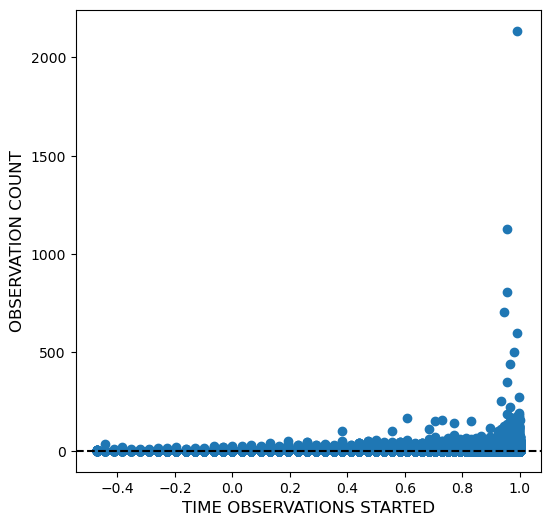

In [46]:
fig, ax = plt.subplots(1,1,figsize = (6,6))

ax.scatter(np.sin((np.pi/24) * (trainX["TIME OBSERVATIONS STARTED"].to_numpy() + 4)), trainY)
ax.axhline(0,c='k', ls = '--')
ax.set_ylabel("OBSERVATION COUNT", fontsize=12)
ax.set_xlabel("TIME OBSERVATIONS STARTED", fontsize=12)


plt.show()

In [47]:
def getExponentialModel(column, scale, peak):

    ## transform the given column using the piecewise defined function f(t)
    
    ratio = (24 - peak)/peak

    res = pd.Series(index = column.index)

    beforeIndex = column[column <= peak].index
    res[beforeIndex] = np.exp(-(peak - column.loc[beforeIndex])/scale)
    
    afterIndex = column[column > peak].index
    res[afterIndex] = np.exp(-(column.loc[afterIndex] - peak)/(ratio * scale))

    return res

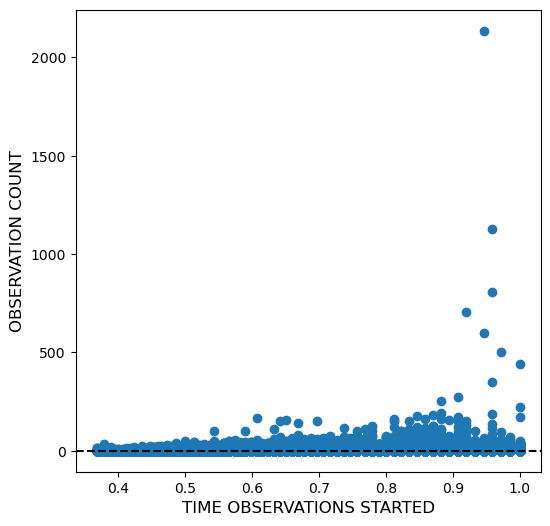

In [48]:
fig, ax = plt.subplots(1,1,figsize = (6,6))

ax.scatter(getExponentialModel(trainX["TIME OBSERVATIONS STARTED"], 6, 6), trainY)
ax.axhline(0,c='k', ls = '--')
ax.set_ylabel("OBSERVATION COUNT", fontsize=12)
ax.set_xlabel("TIME OBSERVATIONS STARTED", fontsize=12)


plt.show()

In [49]:
averaged = findWindowAverageByLoc(windowSize, data)
temp = addWindowAverageByLoc(averaged, data)

rolling = findRollingAverageByLoc(size,data)
temp = addRollingAverageByLoc(rolling, temp)

X,Y,Dates = processData(temp)

X["DURATION MINUTES_TRANSFORMED"] = np.power(X["DURATION MINUTES"].to_numpy(), fraction)

X["TIME OBSERVATIONS STARTED_TRANSFORMED"] = np.sin((np.pi/24) * (X["TIME OBSERVATIONS STARTED"].to_numpy() +4))

trainXs, trainYs, validXs, validYs, trainDates, validDates = getCrossValSplit(X,Y, Dates)

print(f"The cross validation error is {getCrossValLinRegMSE(trainXs, trainYs, validXs, validYs)}")

The cross validation error is 40.62235836323437


In [50]:
averaged = findWindowAverageByLoc(windowSize, data)
temp = addWindowAverageByLoc(averaged, data)

rolling = findRollingAverageByLoc(size,data)
temp = addRollingAverageByLoc(rolling, temp)

X,Y,Dates = processData(temp)

X["DURATION MINUTES_TRANSFORMED"] = np.power(X["DURATION MINUTES"].to_numpy(), fraction)

for scale in [0.5, 1, 1.5, 2, 2.5]:
    for peak in [4, 5, 6, 7, 8]:
        X["TIME OBSERVATIONS STARTED_TRANSFORMED"] = getExponentialModel(X["TIME OBSERVATIONS STARTED"], scale, peak)
        trainXs, trainYs, validXs, validYs, trainDates, validDates = getCrossValSplit(X,Y, Dates)
        print(f"The cross validation error when scale is {scale} and peak is {peak}: {getCrossValLinRegMSE(trainXs, trainYs, validXs, validYs)}")

The cross validation error when scale is 0.5 and peak is 4: 40.62278174919338
The cross validation error when scale is 0.5 and peak is 5: 40.62373461688557
The cross validation error when scale is 0.5 and peak is 6: 40.62313343404662
The cross validation error when scale is 0.5 and peak is 7: 40.596258180385064
The cross validation error when scale is 0.5 and peak is 8: 40.60792591948204
The cross validation error when scale is 1 and peak is 4: 40.61328420258057
The cross validation error when scale is 1 and peak is 5: 40.61101409557605
The cross validation error when scale is 1 and peak is 6: 40.6046586571376
The cross validation error when scale is 1 and peak is 7: 40.58616784487251
The cross validation error when scale is 1 and peak is 8: 40.60569001735631
The cross validation error when scale is 1.5 and peak is 4: 40.609858310142585
The cross validation error when scale is 1.5 and peak is 5: 40.60555428764227
The cross validation error when scale is 1.5 and peak is 6: 40.5976369308

Transforming the variable using the piecewise-defined function
\begin{equation*}
f(t) = 
\begin{cases}
\exp \left ( -\frac{|t-7|}{1.5} \right ) & \text{if $t \leq t_0$, where $t_0$ is the peak time, and }\\
\exp \left ( -\frac{|t-7|}{(1.5)r} \right ) & \text{if $t \geq t_0$,}\\
\end{cases}
\end{equation*}
yields a slightly better result.

In [52]:
scale = 1.5
peak = 7

### Feature selection

We have added quite a bit of variables to our model. So, we will use the feature selection methods from "Linear Regression.ipynb" to determine the important variables.

In [55]:
averaged = findWindowAverageByLoc(windowSize, data)
temp = addWindowAverageByLoc(averaged, data)

rolling = findRollingAverageByLoc(size,data)
temp = addRollingAverageByLoc(rolling, temp)

X,Y,Dates = processData(temp)
X["DURATION MINUTES_TRANSFORMED"] = np.power(X["DURATION MINUTES"].to_numpy(), fraction)
X["TIME OBSERVATIONS STARTED_TRANSFORMED"] = getExponentialModel(X["TIME OBSERVATIONS STARTED"], scale, peak)
trainXs, trainYs, validXs, validYs, trainDates, validDates = getCrossValSplit(X,Y, Dates)

In [56]:
trainX = trainXs[-1]
trainY = trainYs[-1]

linearModel = sm.OLS(trainY, trainX)
results = linearModel.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      OBSERVATION COUNT   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     676.4
Date:                Fri, 21 Aug 2026   Prob (F-statistic):               0.00
Time:                        22:05:34   Log-Likelihood:            -1.0498e+06
No. Observations:              323494   AIC:                         2.100e+06
Df Residuals:                  323472   BIC:                         2.100e+06
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
================================================================================================================
                                                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
IBA CODE                                        -0.1369      0.030     -4.523      0.000      -0.196      -0.078
BCR CODE                                         0.7260      0.067     10.785      0.000       0.594       0.858
USFWS CODE                                      -0.2076      0.083     -2.492      0.013      -0.371      -0.044
LATITUDE                                        -0.0070      0.007     -0.954      0.340      -0.021       0.007
LONGITUDE                                        0.0125      0.005      2.302      0.021       0.002       0.023
OBSERVATION DATE                                 0.0019      0.000      5.340      0.000       0.001       0.003
TIME OBSERVATIONS STARTED                       -0.0223      0.006     -3.864      0.000      -0.034      -0.011
DURATION MINUTES                                -0.0006      0.000     -4.618      0.000      -0.001      -0.000
PRCP                                             0.0002      0.000      1.288      0.198      -0.000       0.001
SNOW                                             0.0086      0.001      9.537      0.000       0.007       0.010
TOBS                                            -0.0147      0.002     -6.638      0.000      -0.019      -0.010
OBSERVATION TYPE_Area                            3.2016      6.214      0.515      0.606      -8.978      15.381
OBSERVATION TYPE_Banding                         0.6842      6.233      0.110      0.913     -11.532      12.900
OBSERVATION TYPE_Historical                      1.1525      6.217      0.185      0.853     -11.032      13.337
OBSERVATION TYPE_Incidental                  -4.449e-15    1.4e-14     -0.318      0.751   -3.19e-14     2.3e-14
OBSERVATION TYPE_Nocturnal Flight Call Count     1.7296      6.515      0.265      0.791     -11.039      14.499
OBSERVATION TYPE_Stationary                      2.0599      6.212      0.332      0.740     -10.115      14.235
OBSERVATION TYPE_Traveling                       1.4670      6.212      0.236      0.813     -10.708      13.642
PREVIOUS AVERAGE OBSERVATION                     0.2425      0.014     16.863      0.000       0.214       0.271
ROLLING AVERAGE OBSERVATION                      0.5248      0.015     35.456      0.000       0.496       0.554
INTERCEPT                                       -5.0605      6.234     -0.812      0.417     -17.279       7.158
DURATION MINUTES_TRANSFORMED                     1.3817      0.020     67.926      0.000       1.342       1.422
TIME OBSERVATIONS STARTED_TRANSFORMED            0.9961      0.079     12.568      0.000       0.841       1.151
==============================================================================
Omnibus:                  1492876.918   Durbin-Watson:            

In [57]:
def getBadColsLinReg(X,Y,pValue):

    ## Return a list of column labels with p-values corresponding to the t-statistic greater than pValue
    
    model = sm.OLS(Y, X)
    res = linearModel.fit()
    coeffs = pd.read_csv(io.StringIO(res.summary().tables[1].as_csv()))
    badCols = list(coeffs[coeffs["P>|t| "] > pValue].iloc[:,0].values)
    badCols = list(map(lambda x : x.rstrip(), badCols))
    if "INTERCEPT" in badCols:
        badCols.remove("INTERCEPT")
    return badCols



def computeOmissionF(X,Y, badCols):

    ## compute the F-statistic and return the corresponding p-value
    
    n = len(X)
    p = len(X.columns)-1
    q = len(badCols)
    
    temp = X.drop(badCols, axis = 1)

    model1 = sm.OLS(Y,X)
    res1 = model1.fit()
    RSS = res1.ssr
    
    model2 = sm.OLS(Y, temp)
    res2 = model2.fit()
    RSS0 = res2.ssr
    
    F = ((RSS0 - RSS)/q)/(RSS/(n-p-1))
    
    return scipy.stats.f.pdf(F, q,n-p-1)

In [58]:
bCols = getBadColsLinReg(trainX, trainY, 0.8)

print(f"The column labels with high p-values are\n{bCols}.\nThe F-statistic has a p-value of {computeOmissionF(trainX, trainY, bCols)}")

The column labels with high p-values are
['OBSERVATION TYPE_Banding', 'OBSERVATION TYPE_Historical', 'OBSERVATION TYPE_Traveling'].
The F-statistic has a p-value of 0.33206041021603133


In [59]:
averaged = findWindowAverageByLoc(windowSize, data)
temp = addWindowAverageByLoc(averaged, data)

rolling = findRollingAverageByLoc(size,data)
temp = addRollingAverageByLoc(rolling, temp)

X,Y,Dates = processData(temp)
X["DURATION MINUTES_TRANSFORMED"] = np.power(X["DURATION MINUTES"].to_numpy(), fraction)
X["TIME OBSERVATIONS STARTED_TRANSFORMED"] = getExponentialModel(X["TIME OBSERVATIONS STARTED"], scale, peak)
trainXs, trainYs, validXs, validYs, trainDates, validDates = getCrossValSplit(X,Y, Dates)


X = X.drop(bCols, axis = 1)

trainXs, trainYs, validXs, validYs, trainDates, validDates = getCrossValSplit(X,Y, Dates)

print(f"The cross validation error is {getCrossValLinRegMSE(trainXs, trainYs, validXs, validYs)}")

The cross validation error is 40.58386394477337


In [60]:
def getHighVIFCols(X, threshold):

    ## Return the column labels whose VIFs are above the given threshold
    
    temp = X.drop("INTERCEPT", axis = 1)
    vals = [VIF(temp, i) for i in range(len(temp.columns))]
    vif = pd.DataFrame({'vif':vals}, index = temp.columns)
    return vif[vif["vif"] > threshold]


def dropHighVIFCols(X,Y,threshold):

    ## Drop the highly collinear variables one-by-one, and record the change in R^2 at each step
    
    droppedCols = []
    scores = []

    cols = getHighVIFCols(X,threshold)
    temp = X
    
    while len(cols) != 0:
        col = cols["vif"].idxmax()
        temp = temp.drop(col, axis = 1)
        model = sm.OLS(Y, X)
        res = model.fit()
        score = res.rsquared
        droppedCols.append(col)
        scores.append(score)
        cols = getHighVIFCols(temp,threshold)

    return droppedCols, scores
    

In [61]:
trainX = trainXs[-1]
trainY = trainYs[-1]

noInfoCols = []

for col in trainX.columns:
    if col == "INTERCEPT":
        continue
    if np.std(trainX[col]) == 0:
        noInfoCols.append(col)

print(f"The columns with zero sample deviation are\n{noInfoCols}")

The columns with zero sample deviation are
['OBSERVATION TYPE_Incidental']


In [62]:
trainX = trainX.drop(noInfoCols, axis = 1)

collinCols, scores = dropHighVIFCols(trainX, trainY, 20)

print(f"The columns with high VIFs are\n{collinCols}.\nThe R^2 scores after dropping the respective columns are\n{scores}")

The columns with high VIFs are
['LONGITUDE', 'LATITUDE', 'OBSERVATION DATE', 'BCR CODE'].
The R^2 scores after dropping the respective columns are
[0.04205301813811546, 0.04205301813811546, 0.04205301813811546, 0.04205301813811546]


In [63]:
averaged = findWindowAverageByLoc(windowSize, data)
temp = addWindowAverageByLoc(averaged, data)

rolling = findRollingAverageByLoc(size,data)
temp = addRollingAverageByLoc(rolling, temp)

X,Y,Dates = processData(temp)
X["DURATION MINUTES_TRANSFORMED"] = np.power(X["DURATION MINUTES"].to_numpy(), fraction)
X["TIME OBSERVATIONS STARTED_TRANSFORMED"] = getExponentialModel(X["TIME OBSERVATIONS STARTED"], scale, peak)

X = X.drop(bCols + noInfoCols + collinCols, axis = 1)

trainXs, trainYs, validXs, validYs, trainDates, validDates = getCrossValSplit(X,Y, Dates)

print(f"The cross validation error is {getCrossValLinRegMSE(trainXs, trainYs, validXs, validYs)}")

The cross validation error is 40.563156368757845


In [64]:
def getCrossValRegMSE(trainXs, trainYs, validXs, validYs, weight, alpha):

    ## Compute the cross validation error for regualrized linear regression when the parameter is alpha.
    ## Lasso regularization is used when weight is 1, and Ridge regularization is used when weight is 0.
    
    MSEs = np.zeros(4)

    labels = list(trainXs[-1].columns)    
    
    alpha = [alpha for _ in range(len(labels))]
    alpha[labels.index("INTERCEPT")] = 0.0
    alpha = np.array(alpha)
    
    for i in range(4):
        trainX, trainY, validX, validY = trainXs[i].astype(float), trainYs[i].astype(float), validXs[i].astype(float), validYs[i].astype(float)
        means = {}
        sds = {}

        continuousCols = ["LATITUDE", "LONGITUDE", "OBSERVATION DATE", "TIME OBSERVATIONS STARTED", "DURATION MINUTES", "PRCP", "SNOW", "TOBS"]

        for col in continuousCols:
            if col not in trainX.columns:
                continue
            means[col] = np.mean(trainX[col].values)
            sds[col] = np.sqrt(np.sum(np.power(trainX[col].values - means[col],2)))
        for col in continuousCols:
            if col not in trainX.columns:
                continue

            trainX.loc[:,col] = (trainX[col] - means[col])/sds[col]
            validX.loc[:,col] = (validX[col] - means[col])/sds[col]
        model = sm.OLS(trainY, trainX)

        results = model.fit_regularized(method = "elastic_net", alpha = alpha, L1_wt = weight)
        preds = results.predict(validX)
        MSEs[i] = np.mean(np.power(validY.values-preds, 2))
    
    return np.mean(MSEs), results.params


def findBestIndex(errors):

    ## Find the index with the smaller error in errors
    
    i = 0
    cur = float("inf")
    curInd = -1
    
    for err in errors:
        if err >= cur:
            i += 1
            continue
        cur = err
        curInd = i
        i +=1
    return curInd

def getOptimalParam(trainXs, trainYs, validXs, validYs, weight, alphas):

    ## Find the optimal parameter for regularization

    n = len(alphas)
    cv_error = np.zeros(n)
    regCoeffs = [ ]
    
    for i in range(n):

        ## Lasso regulariation takes quite a bit of time...
        
        if weight == 1:
            print(i)

        ##
        
        error, coeffs = getCrossValRegMSE(trainXs, trainYs, validXs, validYs, weight, alphas[i])
        cv_error[i] = error
        regCoeffs.append(coeffs)

    bestInd = findBestIndex(cv_error)

    return alphas[bestInd], regCoeffs[bestInd], cv_error[bestInd]

In [105]:
alphas = np.logspace(-5, -1, num = 30)
alpha, coeffs, error = getOptimalParam(trainXs, trainYs, validXs, validYs, 1, alphas)

print(f"The optimal parameter value is {alpha} with a cross validation error of {error}")
print("The optimal regularized coefficients are")
print(coeffs)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
The optimal parameter value is 0.028072162039411756 with a cross validation error of 40.2977329711012
The optimal regularized coefficients are
IBA CODE                                       -0.144819
USFWS CODE                                      0.000000
TIME OBSERVATIONS STARTED                       0.000000
DURATION MINUTES                                0.000000
PRCP                                            0.000000
SNOW                                            0.000000
TOBS                                            0.000000
OBSERVATION TYPE_Area                           0.000000
OBSERVATION TYPE_Nocturnal Flight Call Count    0.000000
OBSERVATION TYPE_Stationary                     0.000000
PREVIOUS AVERAGE OBSERVATION                    0.209365
ROLLING AVERAGE OBSERVATION                     0.545875
INTERCEPT                                      -2.846829
DURATION MINUTES_TRANSFORMED        

We do a linear regression using only the features selected by Lasso Regression.

In [107]:
sigCols = list(coeffs[coeffs != 0].index)


averaged = findWindowAverageByLoc(windowSize, data)
temp = addWindowAverageByLoc(averaged, data)

rolling = findRollingAverageByLoc(size,data)
temp = addRollingAverageByLoc(rolling, temp)

X,Y,Dates = processData(temp)
X["DURATION MINUTES_TRANSFORMED"] = np.power(X["DURATION MINUTES"].to_numpy(), fraction)
X["TIME OBSERVATIONS STARTED_TRANSFORMED"] = getExponentialModel(X["TIME OBSERVATIONS STARTED"], scale, peak)

X = X[sigCols]

trainXs, trainYs, validXs, validYs, trainDates, validDates = getCrossValSplit(X,Y, Dates)

print(f"The cross validation error is {getCrossValLinRegMSE(trainXs, trainYs, validXs, validYs)}")

The cross validation error is 40.31336315017893
